In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
sys.path.append('./SALSA-CLRS/')

import torch
from model.GINE import GINE

from loguru import logger
from baselines.core.models.encoder import Encoder
from baselines.core.models.decoder import Decoder
from baselines.core.loss import CLRSLoss
from salsaclrs import specs

device = torch.device('cuda')

Ks = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
N_edges = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
N_iters = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
prune = True

c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\heje197\AppData\Local\miniconda3\envs\minar\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
from EncodeProcessDecode import EncodeProcessDecode
algorithms = ['bfs', 'dfs', 'dijkstra', 'mst_prim', 'bellman_ford', 'articulation_points', 'bridges']
output_types = {
    'bfs' : 'pointer',
    'dfs' : 'pointer',
    'dijkstra' : 'pointer',
    'mst_prim' : 'pointer',
    'bellman_ford' : 'pointer',
    'articulation_points' : 'mask',
    'bridges' : 'edge_mask',
}
accuracy_types = {
    'bfs' : 'node_accuracy',
    'dfs' : 'node_accuracy',
    'dijkstra' : 'node_accuracy',
    'mst_prim' : 'node_accuracy',
    'bellman_ford' : 'node_accuracy',
    'articulation_points' : 'node_accuracy',
    'bridges' : 'edge_accuracy',
}
logger.disable('baselines.core.models.encoder')
logger.disable('baselines.core.models.decoder')

hidden_dim = 128
encoders = torch.nn.ModuleDict({
    task : Encoder(specs=specs.SPECS[task]) for task in algorithms
})

decoders = torch.nn.ModuleDict({
    task : Decoder(specs=specs.SPECS[task], 
                   hidden_dim = hidden_dim * 2,
                   no_hint=False) for task in algorithms
})

for encoder in encoders.values():
    encoder.to(device)
for decoder in decoders.values():
    decoder.to(device)
processor = GINE(3*128, 128, 2, 128, edge_dim=1, aggr='max')
processor.to(device)
model = EncodeProcessDecode(encoders, decoders, processor, device=device)

model_checkpoint = f'model_in_progress_199'
model_state = torch.load(f'checkpoints/{model_checkpoint}.pt', map_location=device)
model.load_state_dict(model_state)
model.eval()
model.to(device)

EncodeProcessDecode(
  (encoders): ModuleDict(
    (bfs): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (dfs): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (dijkstra): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
      )
    )
    (mst_prim): Encoder(
      (encoder): ModuleDict(
        (pos): NodeBaseEncoder(
          (lin): Linear(in_features=1, out_features=128, bias=True)
        )
        (s): NodeBaseEncoder(
          (lin): Li

In [3]:
clean_directory = './data_clean/'
corrupted_directory = './data_corrupted/'

num_samples = 128
clean_data = {algorithm : [torch.load(f'{clean_directory}/{algorithm}/data_{i}.pt', weights_only=False) for i in range(num_samples)] for algorithm in algorithms}
corrupted_data = {algorithm : [torch.load(f'{corrupted_directory}/{algorithm}/data_{i}.pt', weights_only=False) for i in range(num_samples)] for algorithm in algorithms}
criteria = {algorithm : CLRSLoss(specs=specs.SPECS[algorithm], hidden_loss_type='l2') for algorithm in algorithms}

In [4]:
import os
from SALSACLRSComputationGraph import SALSACLRSComputationGraph
import networkx as nx
compute_scores = ['weight_grad', 'EAP', 'EAP-IG']

G = SALSACLRSComputationGraph(model, special_modules=['convs.0.lin', 'convs.1.lin'])
G.add_module('convs.0.lin', processor.convs[0].lin,
            module_inputs='edge_attr',
            module_outputs=0,
            layer=0)
G.add_module('convs.1.lin', processor.convs[1].lin,
            module_inputs='edge_attr',
            module_outputs=2,
            layer=0)
G.correct_layers()
print(G.number_of_edges())

G_save_string = f'G_scores_new_{model_checkpoint}.pt'
if os.path.exists(f'scored_computation_graphs/{G_save_string}'):
    G_scores = torch.load(f'scored_computation_graphs/{G_save_string}', weights_only=False)
    for edge, data in G_scores.items():
        G.add_edge(*edge, **data)
    print(f'Loaded existing scored computation graph from scored_computation_graphs/{G_save_string}')
else:
    print('Creating new computation graph...')
    for algorithm in algorithms:
        for score_method in compute_scores:
            if score_method == 'EAP-IG':
                print(f'Calculating {score_method} scores for {algorithm}...')
                G.calculate_scores(algorithm, clean_data[algorithm], corrupted_data[algorithm], criteria[algorithm], which=score_method, **{'steps': 20})
            else:
                print(f'Calculating {score_method} scores for {algorithm}...')
                G.calculate_scores(algorithm, clean_data[algorithm], corrupted_data[algorithm], criteria[algorithm], which=score_method)

    # Only save the scores since saving the whole objects pickles the model
    G_scores = {(u,v) : data for u, v, data in G.edges(data=True)}
    torch.save(G_scores, f'scored_computation_graphs/{G_save_string}')

99712
Loaded existing scored computation graph from scored_computation_graphs/G_scores_new_model_in_progress_199.pt


In [5]:
from SALSACLRSComputationGraph import SALSACLRSCircuit

score_methods = ['weight_grad', 'EAP', 'EAP-IG']
circuit_longest_path_path = f'salsa_clrs_circuits_longest_path_new_prune={prune}_{model_checkpoint}.pt'
circuit_top_K_path = f'salsa_clrs_circuits_top_K_new_prune={prune}_{model_checkpoint}.pt'
circuit_greedy_path = f'salsa_clrs_circuits_greedy_new_prune={prune}_{model_checkpoint}.pt'

if os.path.exists(f'circuits/{circuit_longest_path_path}'):
    circuits_longest_path = torch.load(f'circuits/{circuit_longest_path_path}', weights_only=False)
else:
    circuits_longest_path = {}
if os.path.exists(f'circuits/{circuit_top_K_path}'):
    circuits_top_K = torch.load(f'circuits/{circuit_top_K_path}', weights_only=False)
else:
    circuits_top_K = {}
if os.path.exists(f'circuits/{circuit_greedy_path}'):
    circuits_greedy = torch.load(f'circuits/{circuit_greedy_path}', weights_only=False)
else:
    circuits_greedy = {}
for K, N_edge, N_iter in zip(Ks, N_edges, N_iters):
    skipped = False
    skipped_top_K = False
    skipped_greedy = False

    for algorithm in algorithms:
        for score_method in score_methods:
            if (algorithm, K, score_method) in circuits_longest_path:
                print(f'Circuit for {algorithm} with K={K} and score method {score_method} already exists. Skipping...')
                skipped = True
            else:
                circuits_longest_path[(algorithm, K, score_method)] = SALSACLRSCircuit(model, G, K, key=f'{score_method}_{algorithm}', circuit_algorithm='longest_path')
                print(f'{algorithm} circuit with K={K} and score method {score_method}: {circuits_longest_path[(algorithm, K, score_method)].number_of_edges()} edges')
            circuits_longest_path[(algorithm, K, score_method)].G = None
            circuits_longest_path[(algorithm, K, score_method)].model = None
            circuits_longest_path[(algorithm, K, score_method)].EncodeProcessDecode = None

            if (algorithm, N_edge, score_method) in circuits_top_K:
                print(f'Top-K circuit for {algorithm} with N={N_edge} and score method {score_method} already exists. Skipping...')
                skipped_top_K = True
            else:
                circuits_top_K[(algorithm, N_edge, score_method)] = SALSACLRSCircuit(model, G, N_edge, circuit_algorithm='top_K', key=f'{score_method}_{algorithm}', prune=prune)
                print(f'Top-K {algorithm} circuit with N={N_edge} and score method {score_method}: {circuits_top_K[(algorithm, N_edge, score_method)].number_of_edges()} edges')
            circuits_top_K[(algorithm, N_edge, score_method)].G = None
            circuits_top_K[(algorithm, N_edge, score_method)].model = None
            circuits_top_K[(algorithm, N_edge, score_method)].EncodeProcessDecode = None

            if (algorithm, N_iter, score_method) in circuits_greedy:
                print(f'Greedy circuit for {algorithm} with N={N_iter} and score method {score_method} already exists. Skipping...')
                skipped_greedy = True
            else:
                circuits_greedy[(algorithm, N_iter, score_method)] = SALSACLRSCircuit(model, G, N_iter, circuit_algorithm='greedy', key=f'{score_method}_{algorithm}', prune=prune)
                print(f'Greedy {algorithm} circuit with N={N_iter} and score method {score_method}: {circuits_greedy[(algorithm, N_iter, score_method)].number_of_edges()} edges')
            circuits_greedy[(algorithm, N_iter, score_method)].G = None
            circuits_greedy[(algorithm, N_iter, score_method)].model = None
            circuits_greedy[(algorithm, N_iter, score_method)].EncodeProcessDecode = None

            if not skipped:
                torch.save(circuits_longest_path, f'circuits/{circuit_longest_path_path}')
            if not skipped_top_K:
                torch.save(circuits_top_K, f'circuits/{circuit_top_K_path}')
            if not skipped_greedy:
                torch.save(circuits_greedy, f'circuits/{circuit_greedy_path}')

for circuit in circuits_longest_path.values():
    circuit.G = G
    circuit.EncodeProcessDecode = model
    circuit.model = processor
for circuit in circuits_top_K.values():
    circuit.G = G
    circuit.EncodeProcessDecode = model
    circuit.model = processor
for circuit in circuits_greedy.values():
    circuit.G = G
    circuit.EncodeProcessDecode = model
    circuit.model = processor

Circuit for bfs with K=1000 and score method weight_grad already exists. Skipping...
Top-K circuit for bfs with N=1000 and score method weight_grad already exists. Skipping...
Greedy circuit for bfs with N=1000 and score method weight_grad already exists. Skipping...
Circuit for bfs with K=1000 and score method EAP already exists. Skipping...
Top-K circuit for bfs with N=1000 and score method EAP already exists. Skipping...
Greedy circuit for bfs with N=1000 and score method EAP already exists. Skipping...
Circuit for bfs with K=1000 and score method EAP-IG already exists. Skipping...
Top-K circuit for bfs with N=1000 and score method EAP-IG already exists. Skipping...
Greedy circuit for bfs with N=1000 and score method EAP-IG already exists. Skipping...
Circuit for dfs with K=1000 and score method weight_grad already exists. Skipping...
Top-K circuit for dfs with N=1000 and score method weight_grad already exists. Skipping...
Greedy circuit for dfs with N=1000 and score method weight_

In [6]:
# Get model baseline performance and embeddings
from salsaclrs.data import SALSACLRSDataLoader
from baselines.core.metrics import calc_metrics

try:
    acc_model = torch.load(f'metrics/acc_model_new_{model_checkpoint}.pt', weights_only=False)
except:
    acc_model = {}
    for task in algorithms:
        loader = SALSACLRSDataLoader(clean_data[task], batch_size=32, shuffle=False)
        avg_model_acc = 0
        for data in loader:
            data.to(model.device)
            if hasattr(data, 'weights'):
                data.edge_attr = data.weights.unsqueeze(1)
            else:
                data.edge_attr = torch.zeros((data.num_edges, 1), device=model.device)
            data.task = task
            out, _, hidden = model(data)
            if task == 'bridges':
                model_accuracy = calc_metrics(data.outputs[0], out, data, output_types[task])['edge_accuracy'].mean().item()
            else:
                model_accuracy = calc_metrics(data.outputs[0], out, data, output_types[task])['node_accuracy'].mean().item()
            avg_model_acc += model_accuracy / len(loader)
        acc_model[task] = avg_model_acc
    torch.save(acc_model, f'metrics/acc_model_new_{model_checkpoint}.pt')

In [7]:
def characterization_score(circuit_fid, ablate_fid, w_circuit=0.5, w_ablate=0.5):
    assert w_circuit + w_ablate == 1.0, "Weights must sum to 1."
    if circuit_fid == 0 or ablate_fid == 0:
        return 0.0
    return 1 / (w_circuit / (1-circuit_fid) + w_ablate / ablate_fid)

In [8]:
from salsaclrs.data import SALSACLRSDataLoader
from baselines.core.metrics import calc_metrics

def _load_metric(path, description):
    try:
        metric = torch.load(path, weights_only=False)
        print(f'Loaded {description}')
        return metric
    except FileNotFoundError:
        print(f'{description} not found. Initializing empty dict.')
        return {}
    except Exception as e:
        print(f'Failed to load {description}: {e}. Initializing empty dict.')
        return {}

acc_model = _load_metric(f'metrics/acc_model_new_{model_checkpoint}.pt', 'model accuracies')

acc_circuit_longest_path = _load_metric(f'metrics/acc_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt', 'longest path circuit accuracies')
acc_circuit_top_K = _load_metric(f'metrics/acc_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt', 'top-K circuit accuracies')
acc_circuit_greedy = _load_metric(f'metrics/acc_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt', 'greedy circuit accuracies')

acc_ablate_longest_path = _load_metric(f'metrics/acc_ablate_longest_path_new_prune={prune}_{model_checkpoint}.pt', 'ablated circuit accuracies')
acc_ablate_top_K = _load_metric(f'metrics/acc_ablate_top_K_new_prune={prune}_{model_checkpoint}.pt', 'top-K ablated circuit accuracies')
acc_ablate_greedy = _load_metric(f'metrics/acc_ablate_greedy_new_prune={prune}_{model_checkpoint}.pt', 'greedy ablated circuit accuracies')

fid_circuit_longest_path = _load_metric(f'metrics/fid_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt', 'circuit FID scores')
fid_circuit_top_K = _load_metric(f'metrics/fid_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt', 'top-K circuit FID scores')
fid_circuit_greedy = _load_metric(f'metrics/fid_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt', 'greedy circuit FID scores')

fid_ablate_longest_path = _load_metric(f'metrics/fid_ablate_longest_path_new_prune={prune}_{model_checkpoint}.pt', 'ablated circuit FID scores')
fid_ablate_top_K = _load_metric(f'metrics/fid_ablate_top_K_new_prune={prune}_{model_checkpoint}.pt', 'top-K ablated circuit FID scores')
fid_ablate_greedy = _load_metric(f'metrics/fid_ablate_greedy_new_prune={prune}_{model_checkpoint}.pt', 'greedy ablated circuit FID scores')

char_scores_circuit_longest_path = _load_metric(f'metrics/char_scores_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt', 'characterization scores')
char_scores_circuit_top_K = _load_metric(f'metrics/char_scores_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt', 'top-K characterization scores')
char_scores_circuit_greedy = _load_metric(f'metrics/char_scores_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt', 'greedy characterization scores')

batch_size = 32
for task in algorithms:
    print(f'Calculating metrics for {task}...')
    loader = SALSACLRSDataLoader(clean_data[task], batch_size=batch_size, shuffle=False)
    for score_method in score_methods:
        for K, N_edge, N_iter in zip(Ks, N_edges, N_iters):
            if (task, K, score_method) in char_scores_circuit_longest_path and (task, N_edge, score_method) in char_scores_circuit_top_K and (task, N_iter, score_method) in char_scores_circuit_greedy:
                print(f'Metrics for {task} with K={K} and score method {score_method} already exists. Skipping...')
                continue
            circuit_longest_path = circuits_longest_path[(task, K, score_method)]
            circuit_top_K = circuits_top_K[(task, N_edge, score_method)]
            circuit_greedy = circuits_greedy[(task, N_iter, score_method)]

            avg_acc_circuit_longest_path = 0
            avg_acc_circuit_top_K = 0
            avg_acc_circuit_greedy = 0

            avg_acc_ablate_longest_path = 0
            avg_acc_ablate_top_K = 0
            avg_acc_ablate_greedy = 0

            avg_fid_circuit_longest_path = 0
            avg_fid_circuit_top_K = 0
            avg_fid_circuit_greedy = 0

            avg_fid_ablate_longest_path = 0
            avg_fid_ablate_top_K = 0
            avg_fid_ablate_greedy = 0

            for data in loader:
                data.to(device)
                if hasattr(data, 'weights'):
                    data.edge_attr = data.weights.unsqueeze(1)
                else:
                    data.edge_attr = torch.zeros((data.num_edges, 1), device=device)
                data.task = task

                # Original model
                out_model, _, _ = model(data)

                # Circuit model
                out_circuit_longest_path, _, _ = circuit_longest_path.forward(data)
                # Top-K circuit model
                out_circuit_top_K, _, _ = circuit_top_K.forward(data)
                # Greedy circuit model
                out_circuit_greedy, _, _ = circuit_greedy.forward(data)

                # Ablated circuit model
                out_ablate_longest_path, _, _ = circuit_longest_path.ablate_circuit(data)
                # Top-K ablated circuit model
                out_ablate_top_K, _, _ = circuit_top_K.ablate_circuit(data)
                # Ablated greedy circuit model
                out_ablate_greedy, _, _ = circuit_greedy.ablate_circuit(data)

                data_compare = data.clone()
                for output in data_compare.outputs:
                    if task == 'articulation_points' or task == 'bridges':
                        data_compare[output] = out_model[output].detach() > 0
                    else:
                        data_compare[output] = out_model[output].detach()

                circuit_longest_path_accuracy = calc_metrics(data.outputs[0], out_circuit_longest_path, data, output_types[task])[accuracy_types[task]].mean().item()
                circuit_top_K_accuracy = calc_metrics(data.outputs[0], out_circuit_top_K, data, output_types[task])[accuracy_types[task]].mean().item()
                circuit_greedy_accuracy = calc_metrics(data.outputs[0], out_circuit_greedy, data, output_types[task])[accuracy_types[task]].mean().item()

                ablate_longest_path_accuracy = calc_metrics(data.outputs[0], out_ablate_longest_path, data, output_types[task])[accuracy_types[task]].mean().item()
                ablate_top_K_accuracy = calc_metrics(data.outputs[0], out_ablate_top_K, data, output_types[task])[accuracy_types[task]].mean().item()
                ablate_greedy_accuracy = calc_metrics(data.outputs[0], out_ablate_greedy, data, output_types[task])[accuracy_types[task]].mean().item()

                circuit_longest_path_fid = calc_metrics(data.outputs[0], out_circuit_longest_path, data_compare, output_types[task])[accuracy_types[task]].mean().item()
                circuit_top_K_fid = calc_metrics(data.outputs[0], out_circuit_top_K, data_compare, output_types[task])[accuracy_types[task]].mean().item()
                circuit_greedy_fid = calc_metrics(data.outputs[0], out_circuit_greedy, data_compare, output_types[task])[accuracy_types[task]].mean().item()

                ablate_longest_path_fid = calc_metrics(data.outputs[0], out_ablate_longest_path, data_compare, output_types[task])[accuracy_types[task]].mean().item()
                ablate_top_K_fid = calc_metrics(data.outputs[0], out_ablate_top_K, data_compare, output_types[task])[accuracy_types[task]].mean().item()
                ablate_greedy_fid = calc_metrics(data.outputs[0], out_ablate_greedy, data_compare, output_types[task])[accuracy_types[task]].mean().item()

                avg_acc_circuit_longest_path += circuit_longest_path_accuracy
                avg_acc_circuit_top_K += circuit_top_K_accuracy
                avg_acc_circuit_greedy += circuit_greedy_accuracy

                avg_acc_ablate_longest_path += ablate_longest_path_accuracy
                avg_acc_ablate_top_K += ablate_top_K_accuracy
                avg_acc_ablate_greedy += ablate_greedy_accuracy

                avg_fid_circuit_longest_path += circuit_longest_path_fid
                avg_fid_circuit_top_K += circuit_top_K_fid
                avg_fid_circuit_greedy += circuit_greedy_fid

                avg_fid_ablate_longest_path += ablate_longest_path_fid
                avg_fid_ablate_top_K += ablate_top_K_fid
                avg_fid_ablate_greedy += ablate_greedy_fid

            circuit_longest_path_accs = avg_acc_circuit_longest_path / len(loader)
            circuit_top_K_accs = avg_acc_circuit_top_K / len(loader)
            circuit_greedy_accs = avg_acc_circuit_greedy / len(loader)

            ablate_longest_path_accs = avg_acc_ablate_longest_path / len(loader)
            ablate_top_K_accs = avg_acc_ablate_top_K / len(loader)
            ablate_greedy_accs = avg_acc_ablate_greedy / len(loader)

            circuit_longest_path_fids = 1 - avg_fid_circuit_longest_path / len(loader)
            circuit_top_K_fids = 1 - avg_fid_circuit_top_K / len(loader)
            circuit_greedy_fids = 1 - avg_fid_circuit_greedy / len(loader)

            ablate_longest_path_fids = 1 - avg_fid_ablate_longest_path / len(loader)
            ablate_top_K_fids = 1 - avg_fid_ablate_top_K / len(loader)
            ablate_greedy_fids = 1 - avg_fid_ablate_greedy / len(loader)

            c_score_longest_path = characterization_score(circuit_longest_path_fids, ablate_longest_path_fids)
            c_score_top_K = characterization_score(circuit_top_K_fids, ablate_top_K_fids)
            c_score_greedy = characterization_score(circuit_greedy_fids, ablate_greedy_fids)

            print(f'Task: {task}, K: {K}, N edges: {N_edge}, N iters: {N_iter}, Score: {score_method} |'+
                f'\nLongest Path: {circuit_longest_path.number_of_edges()} Edges | Top-K: {circuit_top_K.number_of_edges()} Edges | Greedy: {circuit_greedy.number_of_edges()} Edges'+
                f'\nCircuit Acc: {circuit_longest_path_accs:.4f}, Circuit Top-K Acc: {circuit_top_K_accs:.4f}, Circuit Greedy Acc: {circuit_greedy_accs:.4f}'+
                f'\nAblate Acc: {ablate_longest_path_accs:.4f}, Ablate Top-K Acc: {ablate_top_K_accs:.4f}, Ablate Greedy Acc: {ablate_greedy_accs:.4f}'+
                f'\nCircuit Fid: {circuit_longest_path_fids:.6f}, Circuit Top-K Fid: {circuit_top_K_fids:.6f}, Circuit Greedy Fid: {circuit_greedy_fids:.6f}'+
                f'\nAblate Fid: {ablate_longest_path_fids:.6f}, Ablate Top-K Fid: {ablate_top_K_fids:.6f}, Ablate Greedy Fid: {ablate_greedy_fids:.6f}'+
                f'\nCharacterization Score: {c_score_longest_path:.6f}, Characterization Score Top-K: {c_score_top_K:.6f}, Characterization Score Greedy: {c_score_greedy:.6f}\n')
            
            acc_circuit_longest_path[(task, K, score_method)] = circuit_longest_path_accs
            acc_circuit_top_K[(task, K, score_method)] = circuit_top_K_accs
            acc_circuit_greedy[(task, K, score_method)] = circuit_greedy_accs

            acc_ablate_longest_path[(task, K, score_method)] = ablate_longest_path_accs
            acc_ablate_top_K[(task, K, score_method)] = ablate_top_K_accs
            acc_ablate_greedy[(task, K, score_method)] = ablate_greedy_accs

            fid_circuit_longest_path[(task, K, score_method)] = circuit_longest_path_fids
            fid_circuit_top_K[(task, K, score_method)] = circuit_top_K_fids
            fid_circuit_greedy[(task, K, score_method)] = circuit_greedy_fids

            fid_ablate_longest_path[(task, K, score_method)] = ablate_longest_path_fids
            fid_ablate_top_K[(task, K, score_method)] = ablate_top_K_fids
            fid_ablate_greedy[(task, K, score_method)] = ablate_greedy_fids

            char_scores_circuit_longest_path[(task, K, score_method)] = c_score_longest_path
            char_scores_circuit_top_K[(task, K, score_method)] = c_score_top_K
            char_scores_circuit_greedy[(task, K, score_method)] = c_score_greedy

            torch.save(acc_circuit_longest_path, f'metrics/acc_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(acc_circuit_top_K, f'metrics/acc_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(acc_circuit_greedy, f'metrics/acc_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(acc_ablate_longest_path, f'metrics/acc_ablate_longest_path_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(acc_ablate_top_K, f'metrics/acc_ablate_top_K_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(acc_ablate_greedy, f'metrics/acc_ablate_greedy_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_circuit_longest_path, f'metrics/fid_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_circuit_top_K, f'metrics/fid_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_circuit_greedy, f'metrics/fid_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_ablate_longest_path, f'metrics/fid_ablate_longest_path_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_ablate_top_K, f'metrics/fid_ablate_top_K_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(fid_ablate_greedy, f'metrics/fid_ablate_greedy_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(char_scores_circuit_longest_path, f'metrics/char_scores_circuit_longest_path_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(char_scores_circuit_top_K, f'metrics/char_scores_circuit_top_K_new_prune={prune}_{model_checkpoint}.pt')
            torch.save(char_scores_circuit_greedy, f'metrics/char_scores_circuit_greedy_new_prune={prune}_{model_checkpoint}.pt')

Loaded model accuracies
Loaded longest path circuit accuracies
Loaded top-K circuit accuracies
Loaded greedy circuit accuracies
Loaded ablated circuit accuracies
Loaded top-K ablated circuit accuracies
Loaded greedy ablated circuit accuracies
Loaded circuit FID scores
Loaded top-K circuit FID scores
Loaded greedy circuit FID scores
Loaded ablated circuit FID scores
Loaded top-K ablated circuit FID scores
Loaded greedy ablated circuit FID scores
Loaded characterization scores
Loaded top-K characterization scores
Loaded greedy characterization scores
Calculating metrics for bfs...
Metrics for bfs with K=1000 and score method weight_grad already exists. Skipping...
Metrics for bfs with K=2000 and score method weight_grad already exists. Skipping...
Metrics for bfs with K=3000 and score method weight_grad already exists. Skipping...
Metrics for bfs with K=4000 and score method weight_grad already exists. Skipping...
Metrics for bfs with K=5000 and score method weight_grad already exists. S

2026-05-06 18:34:45.223 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:34:45.362 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:34:45.482 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:34:45.604 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:34:45.749 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:34:45.860 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512


Task: articulation_points, K: 6000, N edges: 6000, N iters: 6000, Score: weight_grad |
Longest Path: 6451 Edges | Top-K: 4910 Edges | Greedy: 5169 Edges
Circuit Acc: 0.8286, Circuit Top-K Acc: 0.8286, Circuit Greedy Acc: 0.8286
Ablate Acc: 0.8286, Ablate Top-K Acc: 0.8286, Ablate Greedy Acc: 0.8286
Circuit Fid: 0.081055, Circuit Top-K Fid: 0.081055, Circuit Greedy Fid: 0.081055
Ablate Fid: 0.081055, Ablate Top-K Fid: 0.081055, Ablate Greedy Fid: 0.081055
Characterization Score: 0.148970, Characterization Score Top-K: 0.148970, Characterization Score Greedy: 0.148970



2026-05-06 18:35:44.601 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:35:44.691 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:35:44.769 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:35:44.851 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:35:44.944 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:35:45.029 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512


Task: articulation_points, K: 7000, N edges: 7000, N iters: 7000, Score: weight_grad |
Longest Path: 7468 Edges | Top-K: 5851 Edges | Greedy: 6142 Edges
Circuit Acc: 0.8286, Circuit Top-K Acc: 0.8286, Circuit Greedy Acc: 0.8286
Ablate Acc: 0.8286, Ablate Top-K Acc: 0.8286, Ablate Greedy Acc: 0.8286
Circuit Fid: 0.081055, Circuit Top-K Fid: 0.081055, Circuit Greedy Fid: 0.081055
Ablate Fid: 0.081055, Ablate Top-K Fid: 0.081055, Ablate Greedy Fid: 0.081055
Characterization Score: 0.148970, Characterization Score Top-K: 0.148970, Characterization Score Greedy: 0.148970



...

Task: articulation_points, K: 8000, N edges: 8000, N iters: 8000, Score: EAP-IG |
Longest Path: 8558 Edges | Top-K: 5147 Edges | Greedy: 6021 Edges
Circuit Acc: 0.8286, Circuit Top-K Acc: 0.8286, Circuit Greedy Acc: 0.8286
Ablate Acc: 0.8286, Ablate Top-K Acc: 0.8286, Ablate Greedy Acc: 0.8286
Circuit Fid: 0.081055, Circuit Top-K Fid: 0.081055, Circuit Greedy Fid: 0.081055
Ablate Fid: 0.081055, Ablate Top-K Fid: 0.081055, Ablate Greedy Fid: 0.081055
Characterization Score: 0.148970, Characterization Score Top-K: 0.148970, Characterization Score Greedy: 0.148970



2026-05-06 18:47:58.873 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:47:58.956 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:47:59.033 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:47:59.113 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:47:59.201 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:47:59.284 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512


Task: articulation_points, K: 9000, N edges: 9000, N iters: 9000, Score: EAP-IG |
Longest Path: 9578 Edges | Top-K: 6127 Edges | Greedy: 6830 Edges
Circuit Acc: 0.8286, Circuit Top-K Acc: 0.8286, Circuit Greedy Acc: 0.8286
Ablate Acc: 0.8286, Ablate Top-K Acc: 0.8286, Ablate Greedy Acc: 0.8286
Circuit Fid: 0.081055, Circuit Top-K Fid: 0.081055, Circuit Greedy Fid: 0.081055
Ablate Fid: 0.081055, Ablate Top-K Fid: 0.081055, Ablate Greedy Fid: 0.081055
Characterization Score: 0.148970, Characterization Score Top-K: 0.148970, Characterization Score Greedy: 0.148970



2026-05-06 18:49:37.708 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:49:38.023 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:49:38.252 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:49:38.583 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:49:38.816 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512
2026-05-06 18:49:39.107 | WARNING  | baselines.core.metrics:calc_metrics:52 - MASK METRIC: Truth has less than 5% ones: 25 / 512


Task: articulation_points, K: 10000, N edges: 10000, N iters: 10000, Score: EAP-IG |
Longest Path: 10596 Edges | Top-K: 7000 Edges | Greedy: 7664 Edges
Circuit Acc: 0.8286, Circuit Top-K Acc: 0.8286, Circuit Greedy Acc: 0.8286
Ablate Acc: 0.8286, Ablate Top-K Acc: 0.8286, Ablate Greedy Acc: 0.8286
Circuit Fid: 0.081055, Circuit Top-K Fid: 0.081055, Circuit Greedy Fid: 0.081055
Ablate Fid: 0.081055, Ablate Top-K Fid: 0.081055, Ablate Greedy Fid: 0.081055
Characterization Score: 0.148970, Characterization Score Top-K: 0.148970, Characterization Score Greedy: 0.148970

Calculating metrics for bridges...
Metrics for bridges with K=1000 and score method weight_grad already exists. Skipping...
Metrics for bridges with K=2000 and score method weight_grad already exists. Skipping...
Metrics for bridges with K=3000 and score method weight_grad already exists. Skipping...
Metrics for bridges with K=4000 and score method weight_grad already exists. Skipping...
Metrics for bridges with K=5000 and 

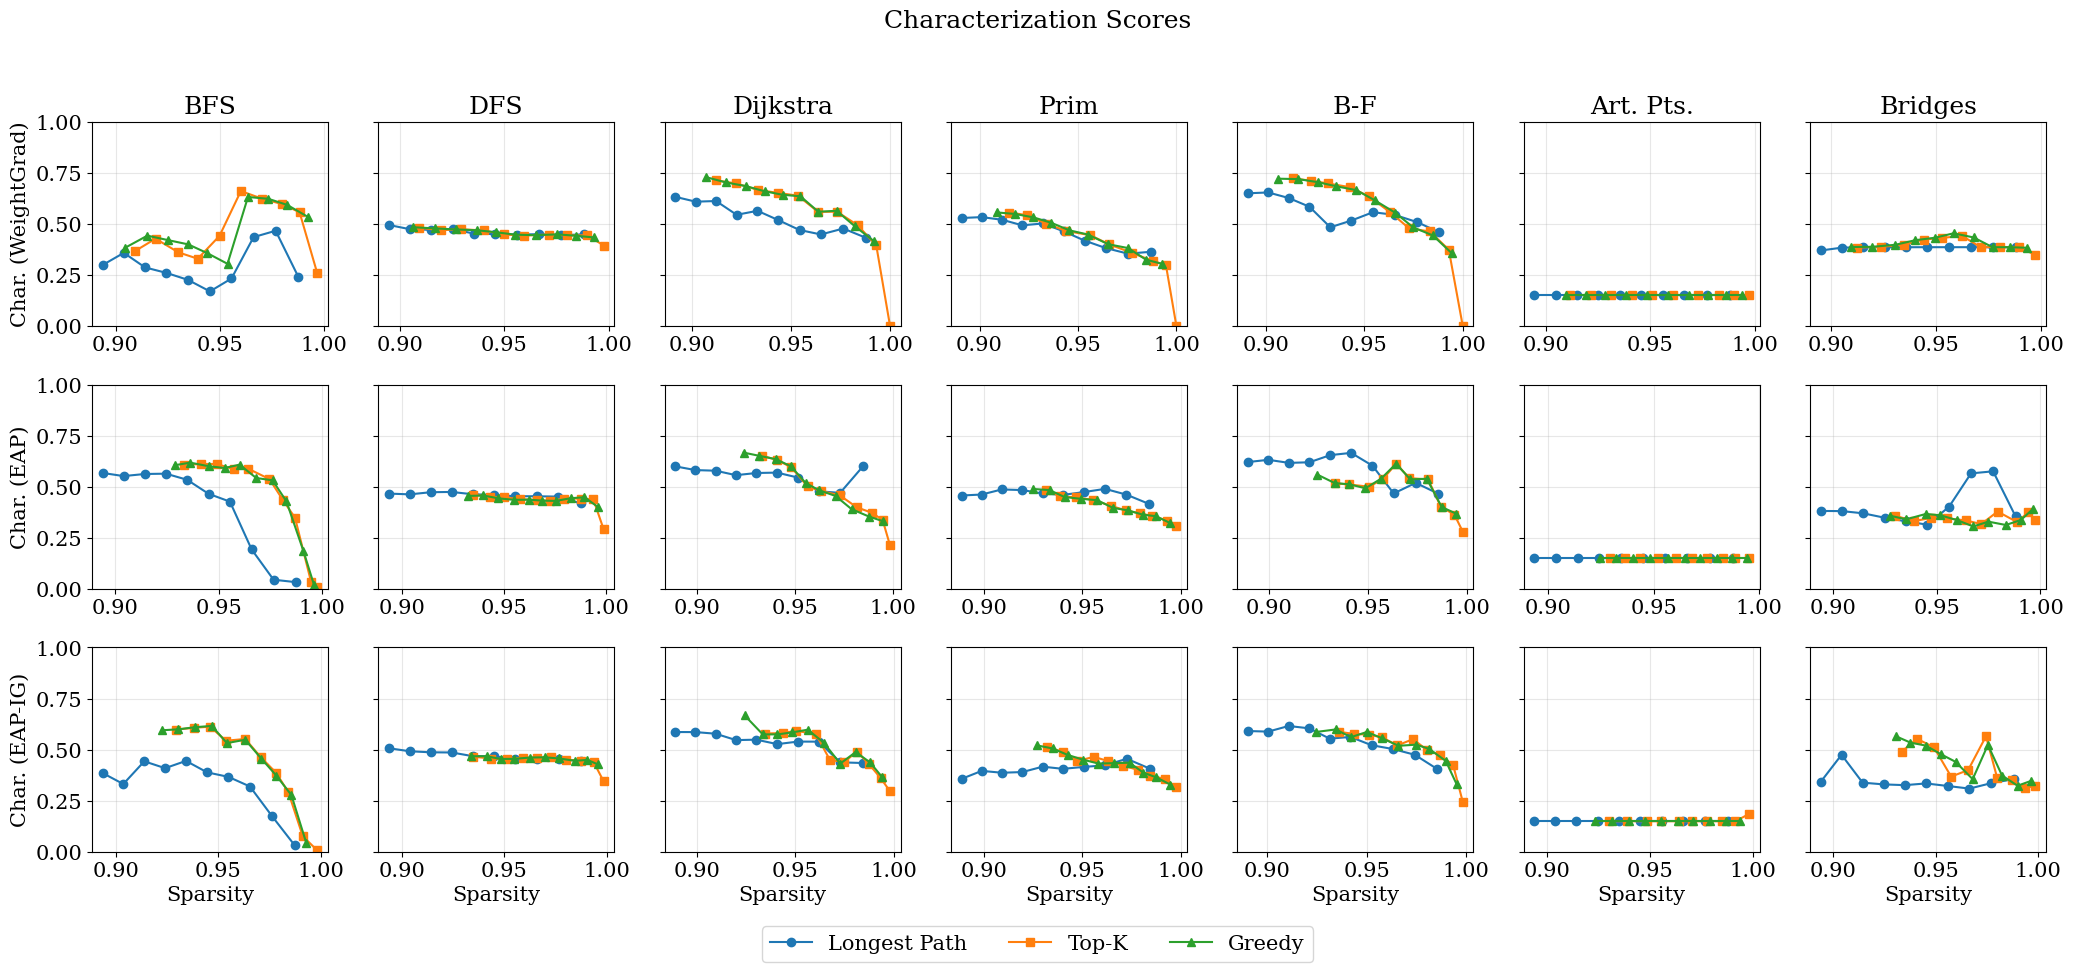

In [ ]:
import math
import matplotlib.pyplot as plt

tasks = algorithms
total_number_of_edges = G.number_of_edges()
plt.rcParams.update({'font.size': 15, 'font.family': 'serif'})
algorithms_plotting = ['BFS', 'DFS', 'Dijkstra', 'Prim', 'B-F', 'Art. Pts.', 'Bridges']
score_methods_plotting = ['WeightGrad', 'EAP', 'EAP-IG']

def edge_count_to_model_sparsity(edge_count):
    return 1 - edge_count / total_number_of_edges

n_cols = 7
n_rows = len(score_methods)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharey=True)

for (n, score_key) in enumerate(score_methods):
    for i, task in enumerate(tasks):
        ax = axes[n][i]

        x_longest, y_longest = [], []
        x_topn, y_topn = [], []
        x_greedy, y_greedy = [], []

        for idx, k in enumerate(Ks):
            n_edge = N_edges[idx]
            n_iter = N_iters[idx]

            # Longest-path circuit (keyed by K)
            c_longest = circuits_longest_path.get((task, k, score_key))
            if c_longest is not None:
                x_longest.append(edge_count_to_model_sparsity(c_longest.number_of_edges()))
                y_longest.append(characterization_score(
                    fid_circuit_longest_path[(task, k, score_key)],
                    fid_ablate_longest_path[(task, k, score_key)]
                ))

            # Top-K circuit (keyed by N_edge)
            c_topn = circuits_top_K.get((task, n_edge, score_key))
            if c_topn is not None:
                x_topn.append(edge_count_to_model_sparsity(c_topn.number_of_edges()))
                y_topn.append(characterization_score(
                    fid_circuit_top_K[(task, n_edge, score_key)],
                    fid_ablate_top_K[(task, n_edge, score_key)]
                ))

            # Greedy circuit (keyed by N_iter)
            c_greedy = circuits_greedy.get((task, n_iter, score_key))
            if c_greedy is not None:
                x_greedy.append(edge_count_to_model_sparsity(c_greedy.number_of_edges()))
                y_greedy.append(characterization_score(
                    fid_circuit_greedy[(task, n_iter, score_key)],
                    fid_ablate_greedy[(task, n_iter, score_key)]
                ))

        ax.plot(x_longest, y_longest, marker='o', label='Longest-path circuit')
        ax.plot(x_topn, y_topn, marker='s', label='Top-K circuit')
        ax.plot(x_greedy, y_greedy, marker='^', label='Greedy circuit')

        if n == 0:
            ax.set_title(algorithms_plotting[i])
        if n == n_rows - 1:
            ax.set_xlabel('Sparsity')
        if i % n_cols == 0:
            ax.set_ylabel(f'Char. ({score_methods_plotting[n]})')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        # ax.legend()

    for j in range(len(tasks), len(axes)):
        axes[j].axis('off')

fig.legend(['Longest Path', 'Top-K', 'Greedy'], loc='lower center', ncol=5, bbox_to_anchor=(0.5, -.05))
plt.savefig(f'figures/characterization_scores_ablation.png', bbox_inches='tight', dpi=300)
plt.savefig(f'figures/characterization_scores_ablation.pdf', bbox_inches='tight')
plt.suptitle(f'Characterization Scores', y=1.02)
plt.tight_layout()
plt.show()

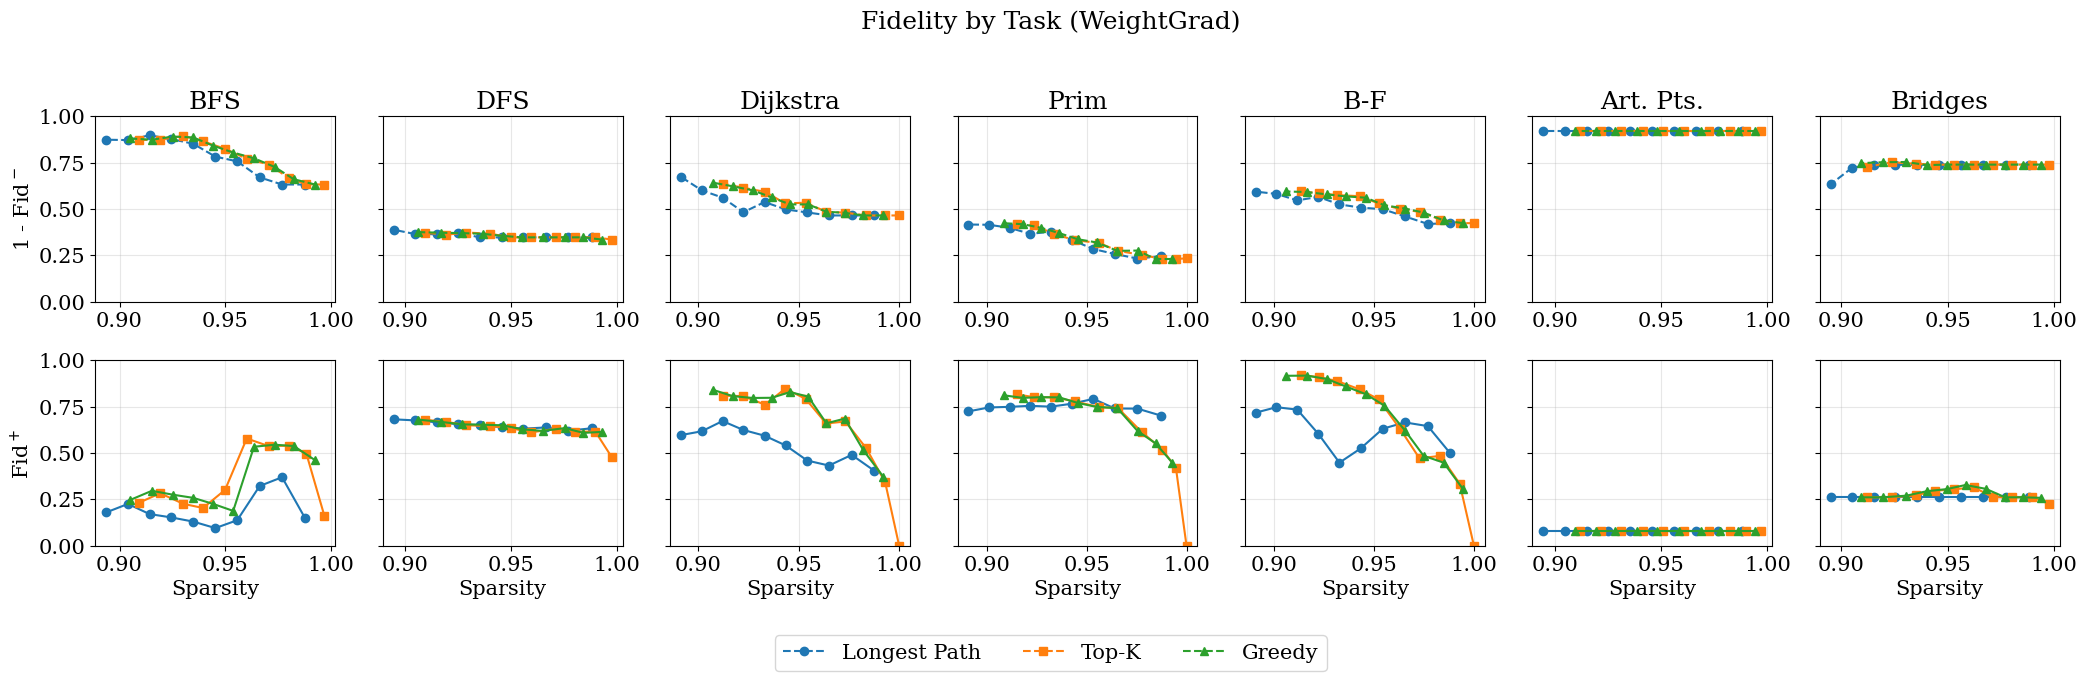

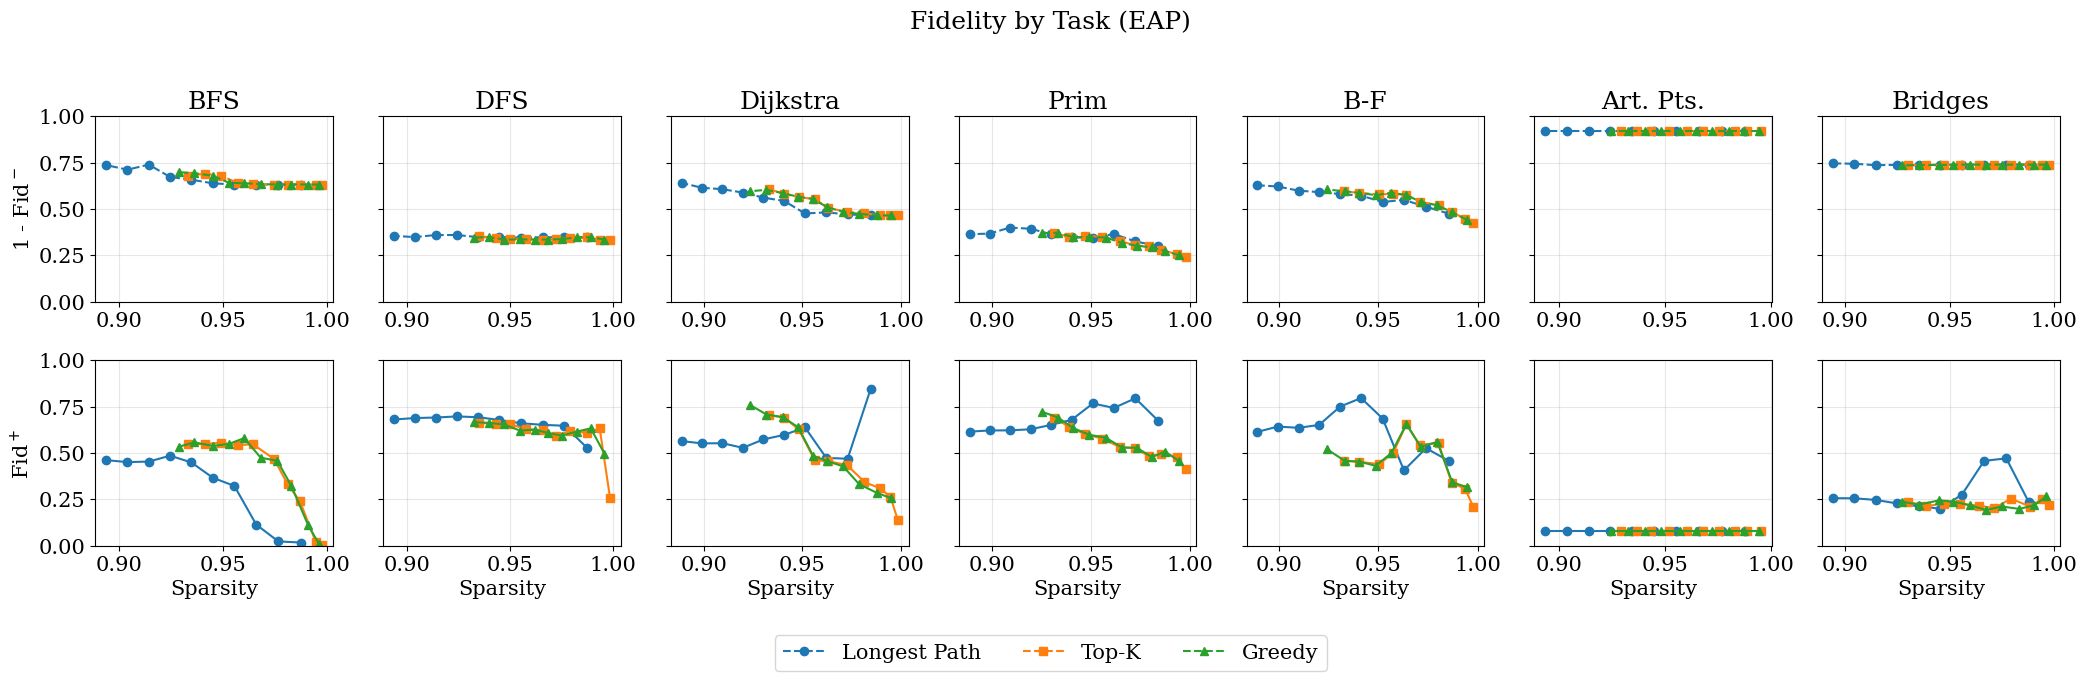

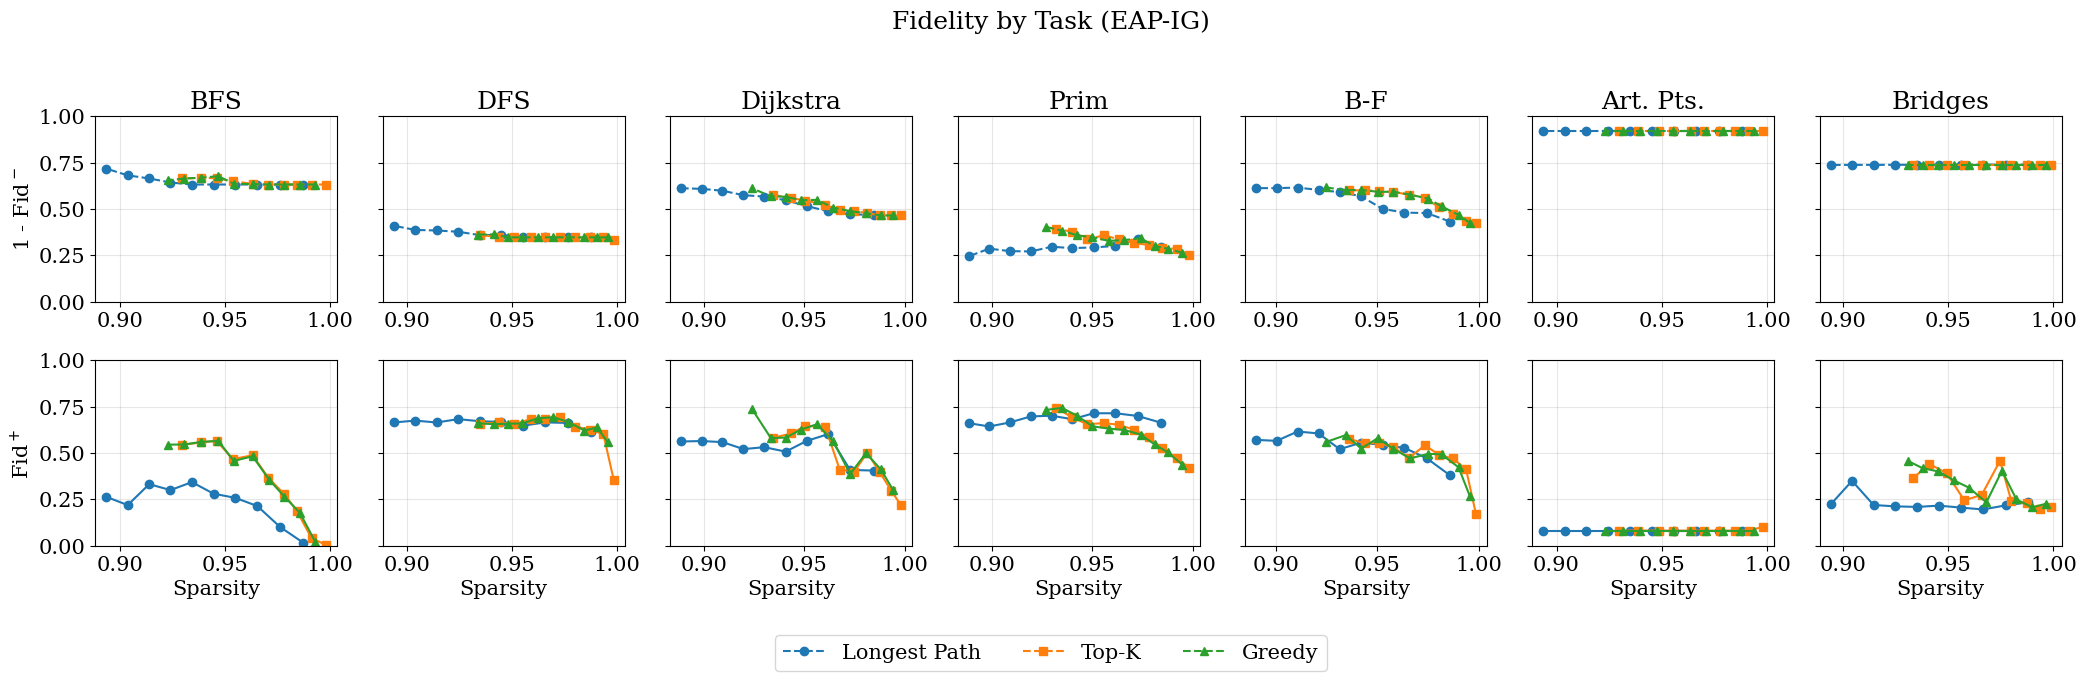

In [ ]:
# Positive vs Negative fidelity in two rows:
# Row 1 = positive fidelity, Row 2 = negative fidelity
# X-axis uses true edge counts from each circuit object.

for score_idx, plot_score_key in enumerate(score_methods):
    n_tasks = len(tasks)
    fig, axes = plt.subplots(2, n_tasks, figsize=(3 * n_tasks, 6), sharex=False, sharey='row')

    for col, task in enumerate(tasks):
        task_ks = sorted({k for (t, k, s) in fid_circuit_longest_path.keys() if t == task and s == plot_score_key})

        x_longest, x_topn, x_greedy = [], [], []
        pos_longest, pos_topn, pos_greedy = [], [], []
        neg_longest, neg_topn, neg_greedy = [], [], []

        for k in task_ks:
            if k not in Ks:
                continue
            idx = Ks.index(k)
            n_edge = N_edges[idx]
            n_iter = N_iters[idx]

            c_longest = circuits_longest_path.get((task, k, plot_score_key))
            c_topn = circuits_top_K.get((task, n_edge, plot_score_key))
            c_greedy = circuits_greedy.get((task, n_iter, plot_score_key))

            if c_longest is not None and (task, k, plot_score_key) in fid_circuit_longest_path and (task, k, plot_score_key) in fid_ablate_longest_path:
                x_longest.append(edge_count_to_model_sparsity(c_longest.number_of_edges()))
                neg_longest.append(1 - fid_circuit_longest_path[(task, k, plot_score_key)])
                pos_longest.append(fid_ablate_longest_path[(task, k, plot_score_key)])

            if c_topn is not None and (task, n_edge, plot_score_key) in fid_circuit_top_K and (task, n_edge, plot_score_key) in fid_ablate_top_K:
                x_topn.append(edge_count_to_model_sparsity(c_topn.number_of_edges()))
                neg_topn.append(1 -fid_circuit_top_K[(task, n_edge, plot_score_key)])
                pos_topn.append(fid_ablate_top_K[(task, n_edge, plot_score_key)])

            if c_greedy is not None and (task, n_iter, plot_score_key) in fid_circuit_greedy and (task, n_iter, plot_score_key) in fid_ablate_greedy:
                x_greedy.append(edge_count_to_model_sparsity(c_greedy.number_of_edges()))
                neg_greedy.append(1 - fid_circuit_greedy[(task, n_iter, plot_score_key)])
                pos_greedy.append(fid_ablate_greedy[(task, n_iter, plot_score_key)])

        ax_neg = axes[0, col]
        ax_pos = axes[1, col]

        ax_neg.plot(x_longest, neg_longest, marker='o', linestyle='--', label='Longest')
        ax_neg.plot(x_topn, neg_topn, marker='s', linestyle='--', label='Top-K')
        ax_neg.plot(x_greedy, neg_greedy, marker='^', linestyle='--', label='Greedy')
        ax_neg.set_title(algorithms_plotting[col])
        ax_neg.grid(True, alpha=0.3)
        ax_neg.set_ylim(0, 1)
        ax_pos.plot(x_longest, pos_longest, marker='o', label='Longest')
        ax_pos.plot(x_topn, pos_topn, marker='s', label='Top-K')
        ax_pos.plot(x_greedy, pos_greedy, marker='^', label='Greedy')
        ax_pos.set_xlabel('Sparsity')
        ax_pos.grid(True, alpha=0.3)
        ax_pos.set_ylim(0, 1)

    axes[0, 0].set_ylabel(r'1 - Fid$^-$')
    axes[1, 0].set_ylabel(r'Fid$^+$')

    # axes[0, -1].legend(fontsize=8, loc='best')
    # axes[1, -1].legend(fontsize=8, loc='best')

    fig.legend(['Longest Path', 'Top-K', 'Greedy'], loc='lower center', ncol=5, bbox_to_anchor=(0.5, -.1))

    plt.suptitle(f'Fidelity by Task ({score_methods_plotting[score_idx]})', y=1.02)
    plt.savefig(f'figures/fidelity_ablation_{plot_score_key}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'figures/fidelity_ablation_{plot_score_key}.pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

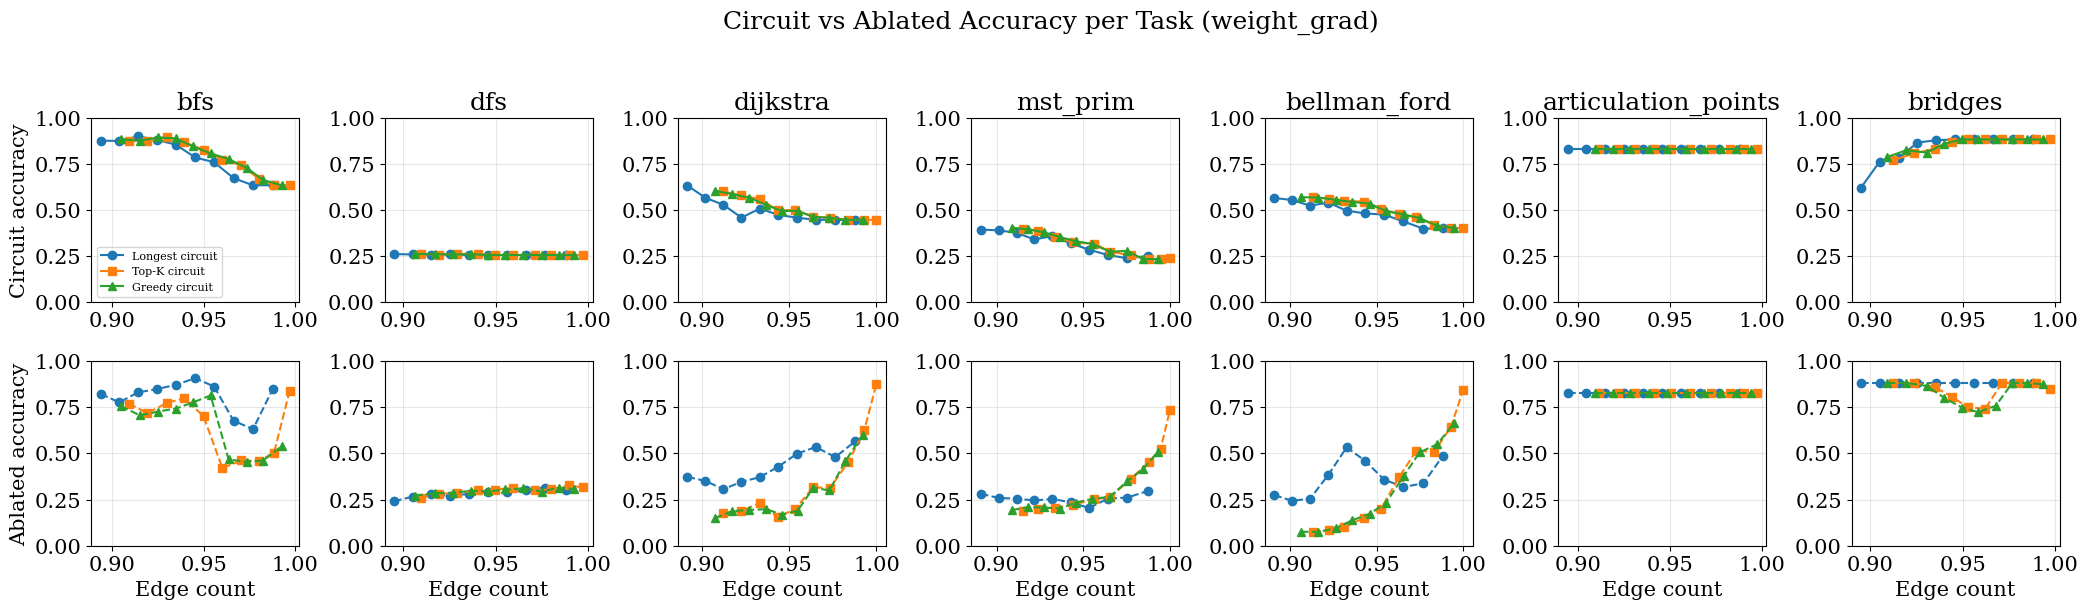

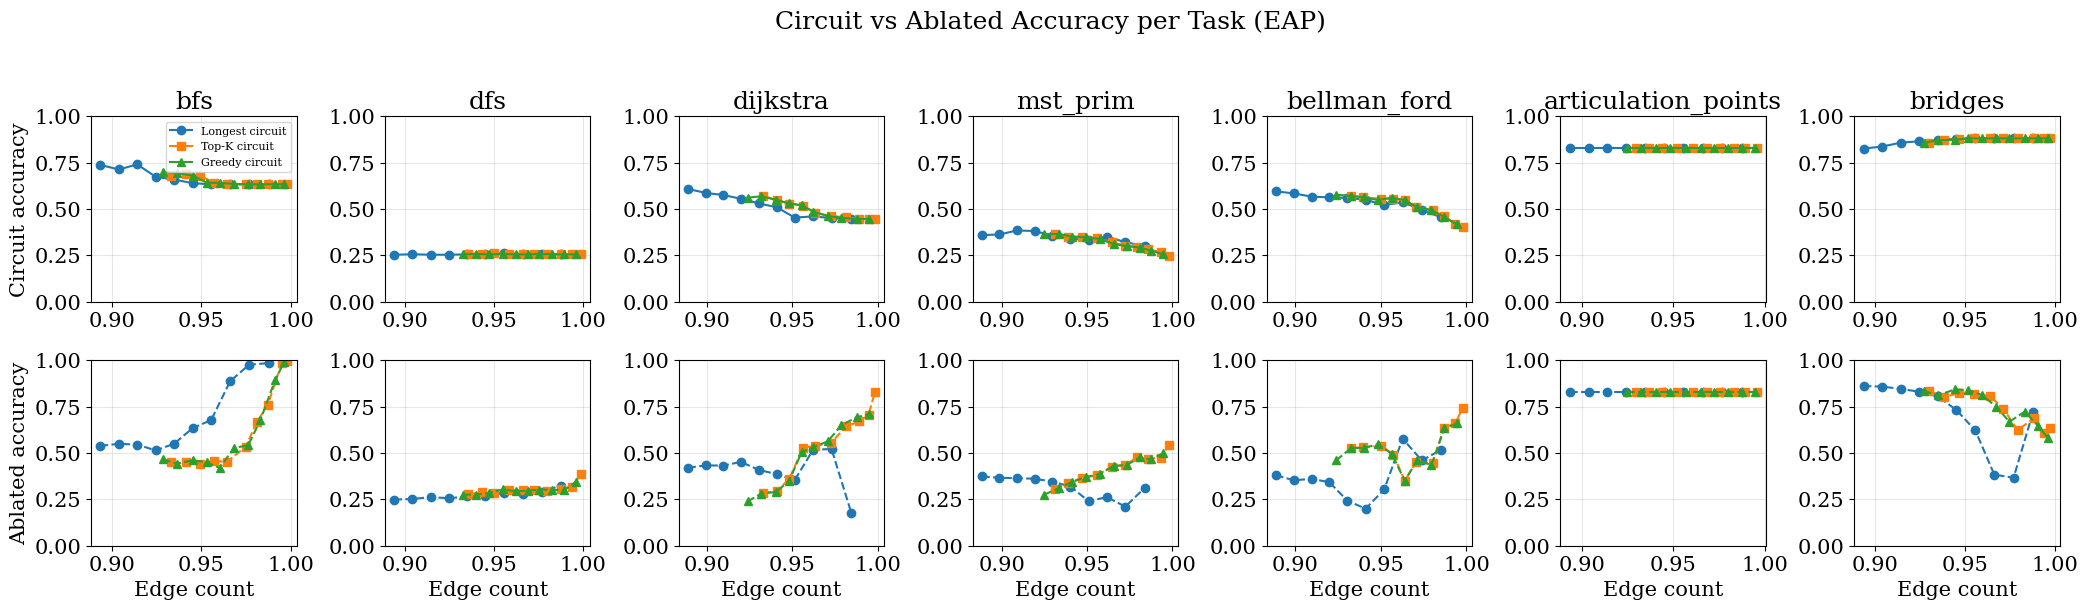

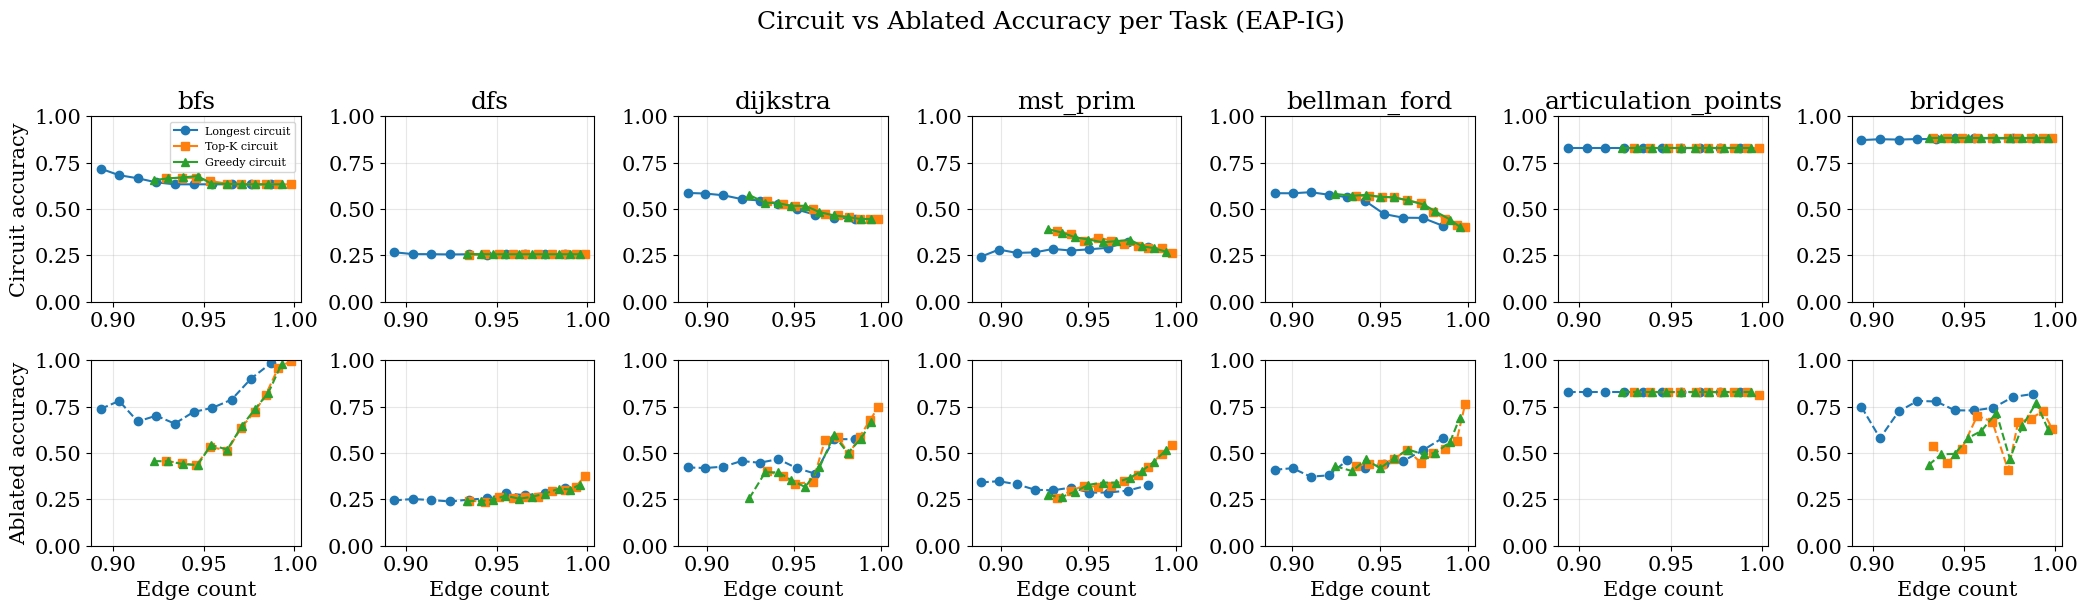

In [11]:
# Plot circuit vs ablated accuracy for each (task, K) combination and each score method.
# Relies on variables already in the notebook: tasks, Ks, N_edges, N_iters, circuits, circuits_top_N, circuits_greedy, score_methods, plt, torch

def _try_load(path):
    try:
        return torch.load(path, weights_only=False)
    except TypeError:
        return torch.load(path)
    except Exception:
        return None

# ensure metric dicts are available (attempt to load if missing)
files = {
    'acc_circuit_longest_path': 'acc_circuit_longest_path_new.pt',
    'acc_ablate_longest_path': 'acc_ablate_longest_path_new.pt',
    'acc_circuit_top_K': 'acc_circuit_top_K_new.pt',
    'acc_ablate_top_K': 'acc_ablate_top_K_new.pt',
    'acc_circuit_greedy': 'acc_circuit_greedy_new.pt',
    'acc_ablate_greedy': 'acc_ablate_greedy_new.pt',
}
for var, fname in files.items():
    if var not in globals():
        data = _try_load(f'metrics/{fname}')
        if data is not None:
            globals()[var] = data

def _get(dname, key):
    d = globals().get(dname, {})
    return d.get(key) if isinstance(d, dict) else None

for score_method in score_methods:
    n_cols = len(tasks)
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6), sharey=False)
    # make axes indexable as axes[row][col] for both n_cols==1 and >1
    if n_cols == 1:
        axes = [[axes[0]], [axes[1]]]
    markers = {'Longest': 'o', 'Top-K': 's', 'Greedy': '^'}

    for col, task in enumerate(tasks):
        ax_top = axes[0][col]
        ax_bot = axes[1][col]

        for label, circuit_getter, acc_name, ablate_name in [
            ('Longest', lambda k,idx: circuits_longest_path.get((task, k, score_method)), 'acc_circuit_longest_path', 'acc_ablate_longest_path'),
            ('Top-K', lambda k,idx: circuits_top_K.get((task, N_edges[idx], score_method)), 'acc_circuit_top_K', 'acc_ablate_top_K'),
            ('Greedy', lambda k,idx: circuits_greedy.get((task, N_iters[idx], score_method)), 'acc_circuit_greedy', 'acc_ablate_greedy'),
        ]:
            xs, yc, ya = [], [], []
            for idx, k in enumerate(Ks):
                c = circuit_getter(k, idx)
                if c is None:
                    continue
                x = edge_count_to_model_sparsity(c.number_of_edges())
                acc_v = _get(acc_name, (task, k, score_method))
                ab_v = _get(ablate_name, (task, k, score_method))
                if acc_v is None or ab_v is None:
                    continue
                xs.append(x); yc.append(acc_v); ya.append(ab_v)

            if not xs:
                continue
            pairs = sorted(zip(xs, yc, ya), key=lambda t: t[0])
            xs_s, yc_s, ya_s = zip(*pairs)

            ax_top.plot(xs_s, yc_s, marker=markers[label], linestyle='-', label=f'{label} circuit')
            ax_bot.plot(xs_s, ya_s, marker=markers[label], linestyle='--', label=f'{label} ablated')

        ax_top.set_title(task)
        ax_top.set_ylim(0, 1)
        ax_bot.set_ylim(0, 1)
        ax_bot.set_xlabel('Edge count')
        if col == 0:
            ax_top.set_ylabel('Circuit accuracy')
            ax_bot.set_ylabel('Ablated accuracy')
            ax_top.legend(fontsize=8, loc='best')
        ax_top.grid(alpha=0.3)
        ax_bot.grid(alpha=0.3)
    plt.suptitle(f'Circuit vs Ablated Accuracy per Task ({score_method})', y=1.02)
    plt.tight_layout()
    plt.show()